# 💹 Day 19 - Stock Price Prediction

In [1]:
# Core Libraries
import os
import warnings
import datetime

# Data Manipulation Libraries
import yfinance as yf
import numpy as np
import pandas as pd

# Data Visualization Libraries
import matplotlib.pyplot as plt
import tensorflow as tf

# Deep Learning Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Machine Learning Libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configurations
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot configuration
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Initalizing required parameters
TICKER = "AAPL"
START_DATE = "2012-01-01"
END_DATE = "2025-01-01"
FEATURE = "Close"
SEQUENCE_LENGTH = 60
TRAIN_SPLIT_DATE = "2021-01-01"
BATCH_SIZE = 32
EPOCHS = 50

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Parameters loaded.")

Parameters loaded.


In [3]:
# Downloading stock data
df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if "Adj Close" not in df.columns:
    df["Adj Close"] = df["Close"]

df = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]]
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

print(f"Download complete. Total rows: {len(df)}")
print('Dataset:')
df.head()

Download complete. Total rows: 3270
Dataset:


Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,12.278333,12.371305,12.266336,12.333216,12.333216,302220800
2012-01-04,12.296328,12.436687,12.274735,12.399497,12.399497,260022000
2012-01-05,12.444780,12.552747,12.376400,12.537152,12.537152,271269600
2012-01-06,12.589341,12.678714,12.572846,12.668218,12.668218,318292800
2012-01-09,12.761190,12.828669,12.636726,12.648123,12.648123,394024400


In [4]:
## 3. FEATURE SELECTION

In [5]:
FEATURES = ["Close", "Volume"]
data = df[FEATURES].fillna(method="ffill").dropna()

print("Features selected:")
data.head()

Features selected:


Price,Close,Volume
Date,,
2012-01-03,12.333216,302220800
2012-01-04,12.399497,260022000
2012-01-05,12.537152,271269600
2012-01-06,12.668218,318292800
2012-01-09,12.648123,394024400


In [6]:
# 4. TRAIN / VALIDATION / TEST SPLIT

In [7]:
train_df = data.loc[:TRAIN_SPLIT_DATE]
test_df = data.loc[TRAIN_SPLIT_DATE:]

val_size = int(len(train_df) * 0.1)
train_main = train_df.iloc[:-val_size]
val_df = train_df.iloc[-val_size:]

print(f"Train: {len(train_main)}\nVal: {len(val_df)}\nTest: {len(test_df)}")

Train: 2039
Val: 226
Test: 1005


In [8]:
# 5. SCALING

In [9]:
scaler = MinMaxScaler().fit(train_main.values)

train_scaled = pd.DataFrame(scaler.transform(train_main), index=train_main.index, columns=train_main.columns)
val_scaled   = pd.DataFrame(scaler.transform(val_df), index=val_df.index, columns=val_df.columns)
test_scaled  = pd.DataFrame(scaler.transform(test_df), index=test_df.index, columns=test_df.columns)

print("Scaling complete.")

Scaling complete.


In [10]:
# 6. CREATE SEQUENCES

In [11]:
def create_sequences(df_scaled, seq_len, tgt_idx):
    X, y = [], []
    data_arr = df_scaled.values
    for i in range(seq_len, len(data_arr)):
        X.append(data_arr[i-seq_len:i])
        y.append(data_arr[i, tgt_idx])
    return np.array(X), np.array(y)

target_index = FEATURES.index(FEATURE)

X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH, target_index)
X_val, y_val     = create_sequences(val_scaled, SEQUENCE_LENGTH, target_index)
X_test, y_test   = create_sequences(test_scaled, SEQUENCE_LENGTH, target_index)

print("X_train:", X_train.shape, "\ny_train:", y_train.shape, "\n")
print("X_val:",   X_val.shape,   "\ny_val:",   y_val.shape, "\n")
print("X_test:",  X_test.shape,  "\ny_test:",  y_test.shape)

X_train: (1979, 60, 2) 
y_train: (1979,) 

X_val: (166, 60, 2) 
y_val: (166,) 

X_test: (945, 60, 2) 
y_test: (945,)


In [12]:
# 7. Model Building and Training

In [13]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 128)             │          67,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118,593 (463.25 KB)

 Trainable params: 118,593 (463.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 8. TRAIN MODEL

In [15]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ModelCheckpoint(os.path.join(MODEL_DIR, "best_model.keras"), save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2
)

print("Training complete.")

Epoch 1/50
62/62 - 14s - 232ms/step - loss: 0.0076 - mae: 0.0496 - val_loss: 0.0191 - val_mae: 0.1141
Epoch 2/50
62/62 - 6s - 92ms/step - loss: 0.0012 - mae: 0.0234 - val_loss: 0.0069 - val_mae: 0.0640
Epoch 3/50
62/62 - 6s - 93ms/step - loss: 0.0011 - mae: 0.0225 - val_loss: 0.0063 - val_mae: 0.0574
Epoch 4/50
62/62 - 10s - 162ms/step - loss: 8.3049e-04 - mae: 0.0195 - val_loss: 0.0078 - val_mae: 0.0727
Epoch 5/50
62/62 - 6s - 91ms/step - loss: 8.1008e-04 - mae: 0.0194 - val_loss: 0.0127 - val_mae: 0.0978
Epoch 6/50
62/62 - 6s - 91ms/step - loss: 7.9256e-04 - mae: 0.0193 - val_loss: 0.0067 - val_mae: 0.0691
Epoch 7/50
62/62 - 6s - 93ms/step - loss: 6.8800e-04 - mae: 0.0185 - val_loss: 0.0050 - val_mae: 0.0545
Epoch 8/50
62/62 - 6s - 92ms/step - loss: 5.6384e-04 - mae: 0.0165 - val_loss: 0.0055 - val_mae: 0.0603
Epoch 9/50
62/62 - 6s - 91ms/step - loss: 6.0158e-04 - mae: 0.0168 - val_loss: 0.0049 - val_mae: 0.0545
Epoch 10/50
62/62 - 6s - 90ms/step - loss: 6.0268e-04 - mae: 0.0167 - va

In [16]:
# 9. TRAINING LOSS PLOT

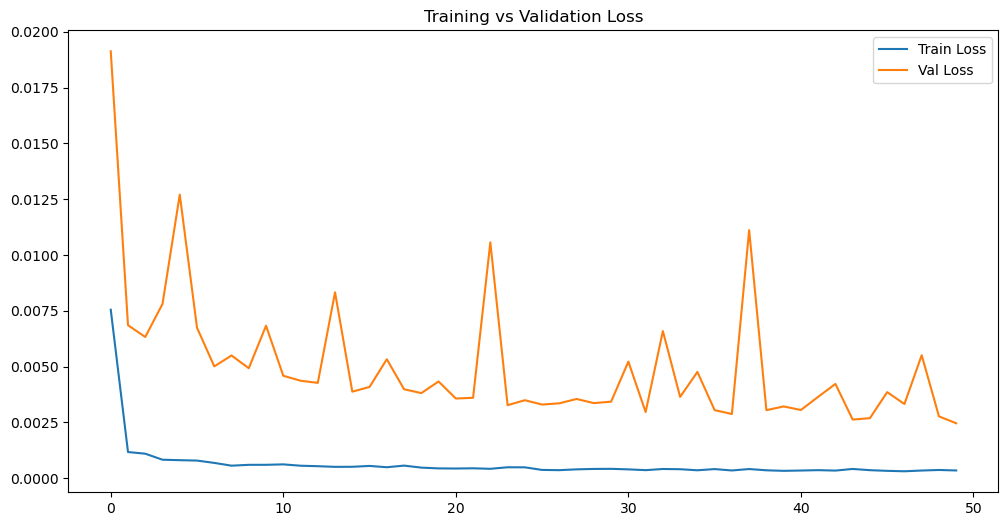

In [17]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [18]:
# 10. INVERSE SCALE & PREDICT

In [19]:
def invert_scaling(values, scaler, tgt_idx, n_features):
    dummy = np.zeros((len(values), n_features))
    dummy[:, tgt_idx] = values
    inv = scaler.inverse_transform(dummy)
    return inv[:, tgt_idx]

n_features = len(FEATURES)

y_pred_scaled = model.predict(X_test)

y_true = invert_scaling(y_test, scaler, target_index, n_features)
y_pred = invert_scaling(y_pred_scaled.flatten(), scaler, target_index, n_features)

test_index = test_scaled.index[SEQUENCE_LENGTH:]
results_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred}, index=test_index)

print("Predicted Dataset:")
results_df.head()

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step  
Predicted Dataset:


,y_true,y_pred
Date,,
2021-03-31,119.084885,119.287207
2021-04-01,119.913551,119.483333
2021-04-05,122.740776,120.111855
2021-04-06,123.043022,121.414428
2021-04-07,124.690598,122.828644


In [20]:
# 11. METRICS

In [21]:
rmse = np.sqrt(mean_squared_error(results_df["y_true"], results_df["y_pred"]))
mae  = mean_absolute_error(results_df["y_true"], results_df["y_pred"])

print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")

RMSE: 5.361
MAE : 3.897


In [22]:
# 12. PLOT RESULTS

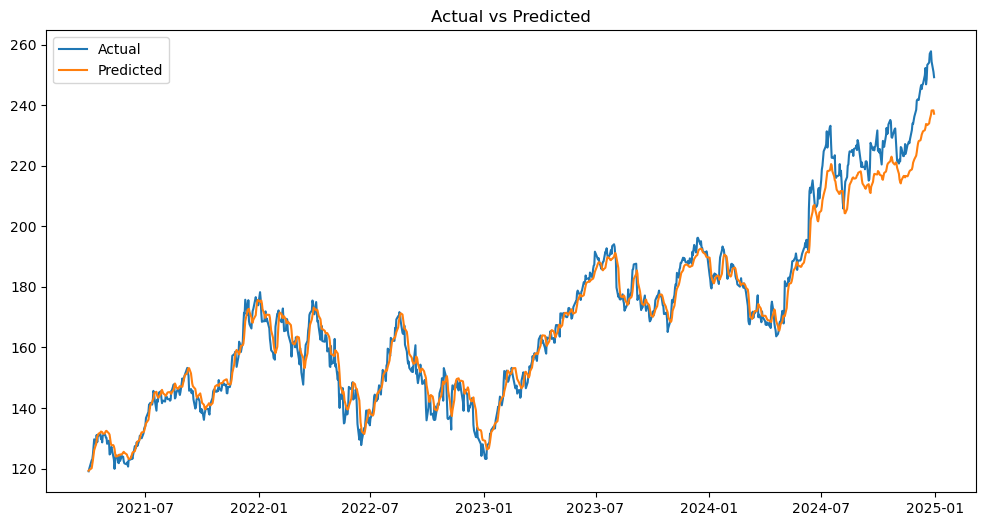

In [23]:
plt.plot(results_df.index, results_df["y_true"], label="Actual")
plt.plot(results_df.index, results_df["y_pred"], label="Predicted")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [24]:
# 13. DIRECTIONAL ACCURACY

In [25]:
true_dir = (results_df["y_true"].diff() > 0).astype(int)[1:]
pred_dir = (results_df["y_pred"].diff() > 0).astype(int)[1:]

direction_acc = (true_dir == pred_dir).mean() * 100
print(f"Directional Accuracy: {direction_acc:.2f}%")

Directional Accuracy: 49.26%


In [26]:
# 14. PREDICT NEXT DAY

In [27]:
last_seq = data[-SEQUENCE_LENGTH:]
last_scaled = scaler.transform(last_seq)
last_scaled = last_scaled.reshape(1, SEQUENCE_LENGTH, n_features)

next_scaled = model.predict(last_scaled)[0][0]
next_price = invert_scaling([next_scaled], scaler, target_index, n_features)[0]

print(f"Next {FEATURE} prediction: {next_price:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Next Close prediction: 235.63
